# **Dataset Overview**:
The Sleep Health and Lifestyle Dataset comprises 400 rows and 13 columns, covering a wide range of variables related to sleep and daily habits. It includes details such as gender, age, occupation, sleep duration, quality of sleep, physical activity level, stress levels, BMI category, blood pressure, heart rate, daily steps, and the presence or absence of sleep disorders.

# **Key Features of the Dataset**:

**Comprehensive Sleep Metrics**: Explore sleep duration, quality, and factors influencing sleep patterns.

**Lifestyle Factors**: Analyze physical activity levels, stress levels, and BMI categories.

**Cardiovascular Health**: Examine blood pressure and heart rate measurements.

**Sleep Disorder Analysis**: Identify the occurrence of sleep disorders such as Insomnia and Sleep Apnea.

# **Dataset Columns**:
**Person ID**: An identifier for each individual.

**Gender**: The gender of the person (Male/Female).

**Age**: The age of the person in years.

**Occupation**: The occupation or profession of the person.

**Sleep Duration (hours)**: The number of hours the person sleeps per day.

**Quality of Sleep (scale: 1-10)**: A subjective rating of the quality of sleep, ranging from 1 to 10.

**Physical Activity Level (minutes/day)**: The number of minutes the person engages in physical activity daily.

**Stress Level (scale: 1-10)**: A subjective rating of the stress level experienced by the person, ranging from 1 to 10.

**BMI Category**: The BMI category of the person (e.g., Underweight, Normal, Overweight). The BMI is defined as the body mass divided by the square of the body height, and is expressed in units of kg/m2.
Major adult BMI classifications are **underweight** (under 18.5 kg/m2), **normal weight** (18.5 to 24.9), **overweight** (25 to 29.9), and **obese** (30 or more).

**Blood Pressure (systolic/diastolic)**: The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.
  
  - 🔴Systolic BP (Top Number):

    Measures the pressure when the heart contracts (pumps blood).
    This is the higher of the two numbers.
    Normal range: 90–120 mmHg

  - 🔵 Diastolic BP (Bottom Number):

    Measures the pressure when the heart relaxes (between beats).
    This is the lower number.
    Normal range: 60–80 mmHg


**Heart Rate (bpm)**: The resting heart rate of the person in beats per minute.

**Daily Steps**: The number of steps the person takes per day.

**Sleep Disorder**: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

# **Details about Sleep Disorder Column**:

**None**: The individual does not exhibit any specific sleep disorder.

**Insomnia**: The individual experiences difficulty falling asleep or staying asleep, leading to inadequate or poor-quality sleep.

**Sleep Apnea**: The individual suffers from pauses in breathing during sleep, resulting in disrupted sleep patterns and potential health risks.

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# **EDA**

In [3]:
df.shape

(374, 13)

**NOTE:** Since we are working with a very small dataset, any manipulation should be done carefully, as it can significantly impact the model's performance.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

**NOTE:** The dataset is clean, except for a single column that contains missing values.

In [6]:
df.drop(columns=["Person ID"], inplace=True)

In [7]:
df.duplicated().sum()

242

**NOTE:** 
- More than half of the dataset consists of duplicate rows. Wow! 
- I have decided not to delete the duplicate rows. Instead, I will create another dataframe without duplicates if needed for the model.

In [8]:
df_no_duplicates = df.drop_duplicates()

In [9]:
df.nunique()

Gender                      2
Age                        31
Occupation                 11
Sleep Duration             27
Quality of Sleep            6
Physical Activity Level    16
Stress Level                6
BMI Category                4
Blood Pressure             25
Heart Rate                 19
Daily Steps                20
Sleep Disorder              2
dtype: int64

In [10]:
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 20)

Unique values in column 'Gender':
['Male' 'Female']
--------------------
Unique values in column 'Age':
[27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 48 49 50 51 52
 53 54 55 56 57 58 59]
--------------------
Unique values in column 'Occupation':
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
--------------------
Unique values in column 'Sleep Duration':
[6.1 6.2 5.9 6.3 7.8 6.  6.5 7.6 7.7 7.9 6.4 7.5 7.2 5.8 6.7 7.3 7.4 7.1
 6.6 6.9 8.  6.8 8.1 8.3 8.5 8.4 8.2]
--------------------
Unique values in column 'Quality of Sleep':
[6 4 7 5 8 9]
--------------------
Unique values in column 'Physical Activity Level':
[42 60 30 40 75 35 45 50 32 70 80 55 90 47 65 85]
--------------------
Unique values in column 'Stress Level':
[6 8 7 4 3 5]
--------------------
Unique values in column 'BMI Category':
['Overweight' 'Normal' 'Obese' 'Normal Weight']
--------------------
Unique values in co

In [11]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [12]:
df.describe().style.background_gradient(cmap = "YlGnBu")

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


### Encoding

In [13]:
df_numeric = df.copy()

# Label Encoding for "Gender"
le_gender = LabelEncoder()
df_numeric['Gender'] = le_gender.fit_transform(df_numeric['Gender'])

# One-Hot Encoding for "Occupation"
df_numeric = pd.get_dummies(df_numeric, columns=['Occupation'], dtype=int)

# Label Encoding for "BMI Category"
le_bmi = LabelEncoder()
df_numeric["BMI Category"] = le_bmi.fit_transform(df_numeric["BMI Category"]) # Make the obes is 3 not 2 because the ordered is not ordinal if it like this

# Split Blood Pressure into Systolic and Diastolic
df_numeric[['Systolic BP', 'Diastolic BP']] = df_numeric['Blood Pressure'].astype(str).str.split('/', expand=True).astype(int)

# Label Encoding for "Sleep Disorder"
le_sleep = LabelEncoder()
df_numeric["Sleep Disorder"] = le_sleep.fit_transform(df_numeric["Sleep Disorder"])

# Drop old Blood Pressure column
df_numeric.drop(columns=["Blood Pressure"], inplace=True)

# Display final transformed DataFrame
df_numeric.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
0,1,27,6.1,6,42,6,3,77,4200,1,...,0,0,0,0,0,0,1,0,126,83
1,1,28,6.2,6,60,8,0,75,10000,1,...,0,0,0,0,0,0,0,0,125,80
2,1,28,6.2,6,60,8,0,75,10000,1,...,0,0,0,0,0,0,0,0,125,80
3,1,28,5.9,4,30,8,2,85,3000,2,...,0,0,0,1,0,0,0,0,140,90
4,1,28,5.9,4,30,8,2,85,3000,2,...,0,0,0,1,0,0,0,0,140,90


In [14]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           374 non-null    int32  
 1   Age                              374 non-null    int64  
 2   Sleep Duration                   374 non-null    float64
 3   Quality of Sleep                 374 non-null    int64  
 4   Physical Activity Level          374 non-null    int64  
 5   Stress Level                     374 non-null    int64  
 6   BMI Category                     374 non-null    int32  
 7   Heart Rate                       374 non-null    int64  
 8   Daily Steps                      374 non-null    int64  
 9   Sleep Disorder                   374 non-null    int32  
 10  Occupation_Accountant            374 non-null    int32  
 11  Occupation_Doctor                374 non-null    int32  
 12  Occupation_Engineer   

In [15]:
df_numeric.describe().style.background_gradient(cmap = "YlGnBu")

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.505348,42.184492,7.132086,7.312834,59.171123,5.385027,1.296791,70.165775,6816.844920,1.002674,0.098930,0.189840,0.168449,0.125668,0.002674,0.195187,0.005348,0.085561,0.010695,0.010695,0.106952,128.553476,84.649733
std,0.500641,8.673133,0.795657,1.196956,20.830804,1.774526,1.431226,4.135676,1617.915679,0.644626,0.298969,0.392699,0.374766,0.331919,0.051709,0.396876,0.073029,0.280090,0.103001,0.103001,0.309466,7.748118,6.161611
min,0.000000,27.000000,5.800000,4.000000,30.000000,3.000000,0.000000,65.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,115.000000,75.000000
25%,0.000000,35.250000,6.400000,6.000000,45.000000,4.000000,0.000000,68.000000,5600.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,125.000000,80.000000
50%,1.000000,43.000000,7.200000,7.000000,60.000000,5.000000,0.000000,70.000000,7000.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,130.000000,85.000000
75%,1.000000,50.000000,7.800000,8.000000,75.000000,7.000000,3.000000,72.000000,8000.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,90.000000
max,1.000000,59.000000,8.500000,9.000000,90.000000,8.000000,3.000000,86.000000,10000.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,142.000000,95.000000


In [16]:
outlier_columns = []

for column in df.select_dtypes(include=['number']).columns: 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    if not outliers.empty:
        outlier_columns.append(column)
        print(f"Column '{column}' has {len(outliers)} outliers.")

print("Columns with outliers:", outlier_columns)

Column 'Heart Rate' has 15 outliers.
Columns with outliers: ['Heart Rate']


**NOTE:** Not that much I'll keep it.

# **Visiualisation**

## **Gender**

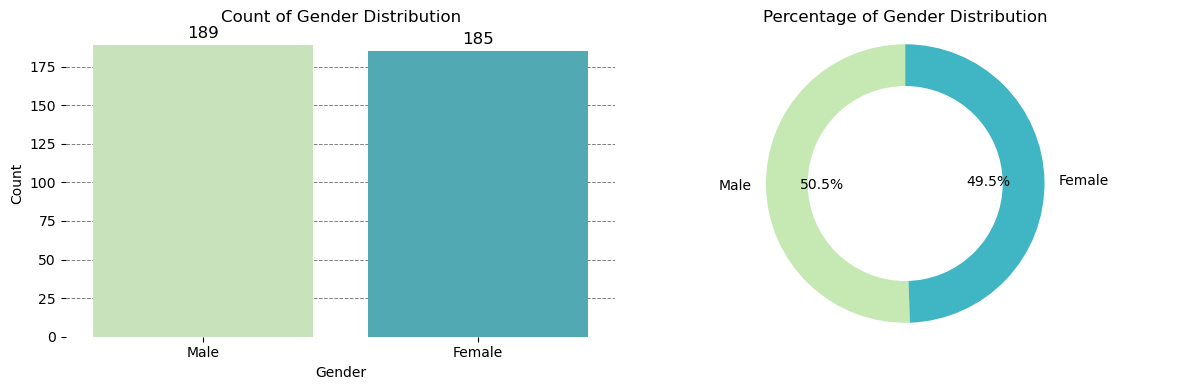

In [18]:
# Create custom color palette
custom_palette = sns.color_palette("YlGnBu", 3)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot for gender distribution
sns.countplot(x='Gender', data=df, ax=axes[0], palette=custom_palette)
axes[0].set_title('Count of Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Annotate countplot with counts
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline',
                     color='black', fontsize=12,
                     xytext=(0, 5),
                     textcoords='offset points')

axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='gray', linestyle='--', linewidth=0.7)
sns.despine(left=True, bottom=True)

# Calculate gender counts
gender_counts = df['Gender'].value_counts()

# Pie chart for percentage of gender distribution
wedges, texts, autotexts = axes[1].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_palette
)

# Add a white circle at the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

axes[1].set_title('Percentage of Gender Distribution')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

#### How does age distribution differ between males and females?

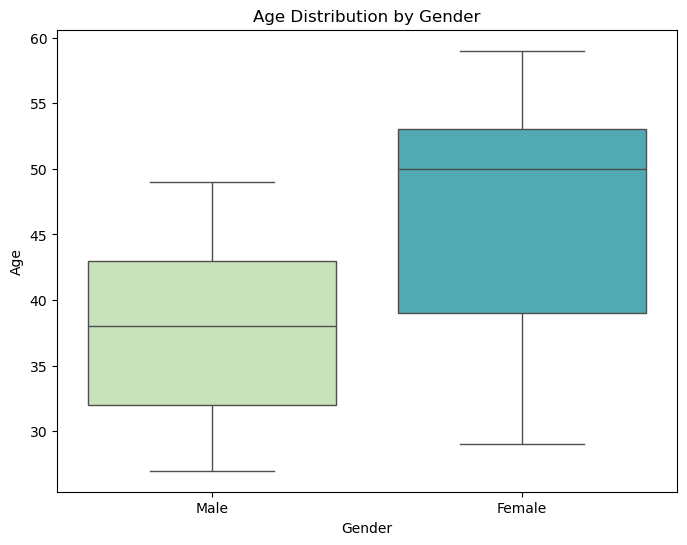

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Gender', y='Age', data=df, palette=custom_palette, ax=ax)
ax.set_title('Age Distribution by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Age')
plt.show()

#### What are the most common occupations among males and females?

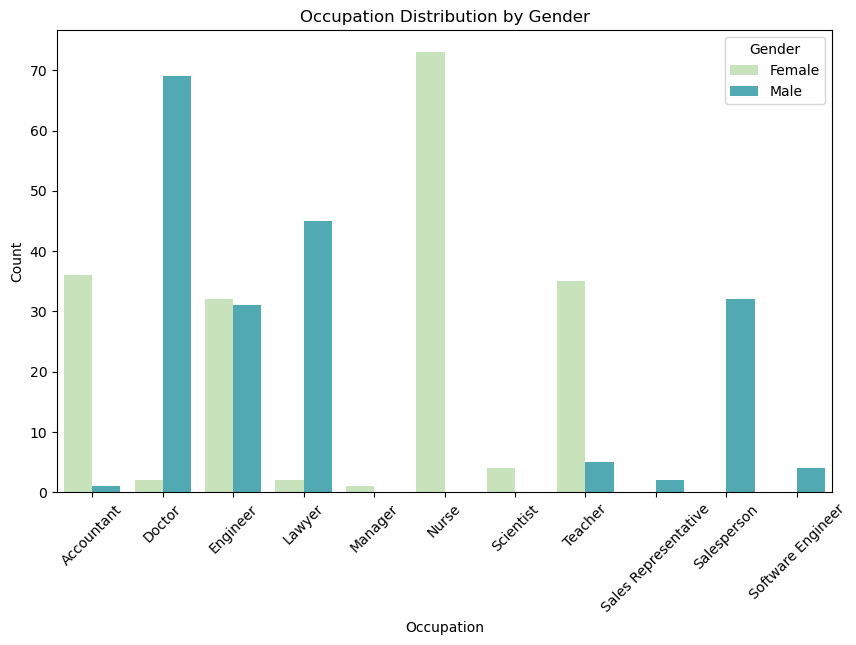

In [20]:
occupation_counts = df.groupby(['Gender', 'Occupation']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Occupation', y='Count', hue='Gender', data=occupation_counts, palette=custom_palette, ax=ax)
ax.set_title('Occupation Distribution by Gender')
ax.set_xlabel('Occupation')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Does quality of sleep differ between males and females?

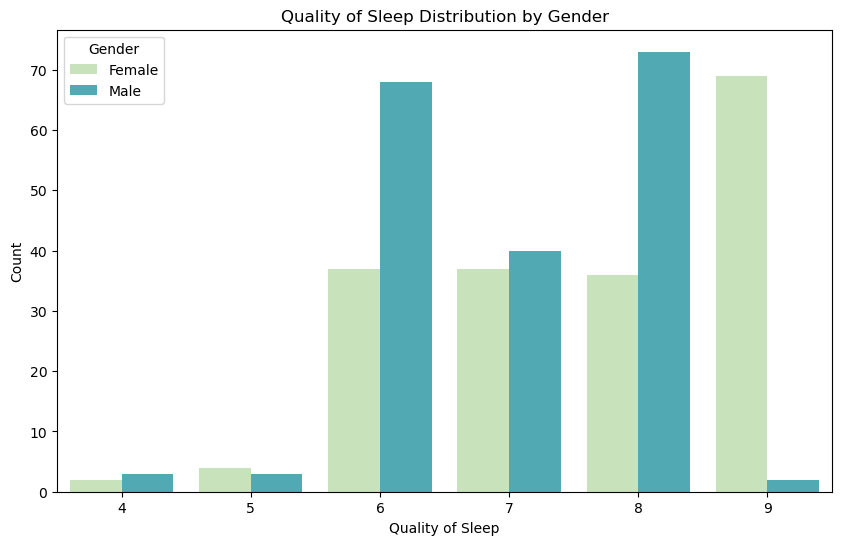

In [22]:
occupation_counts = df.groupby(['Gender', 'Quality of Sleep']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Quality of Sleep', y='Count', hue='Gender', data=occupation_counts, palette=custom_palette, ax=ax)
ax.set_title('Quality of Sleep Distribution by Gender')
ax.set_xlabel('Quality of Sleep')
ax.set_ylabel('Count')
plt.show()

Males generally report higher stress levels than females.

The stress level variability seems slightly greater in females.

This means that Females suffers from High Blood Pressure

Male have more Daily Steps range than Female.

#### Is the prevalence of sleep disorders different between males and females?

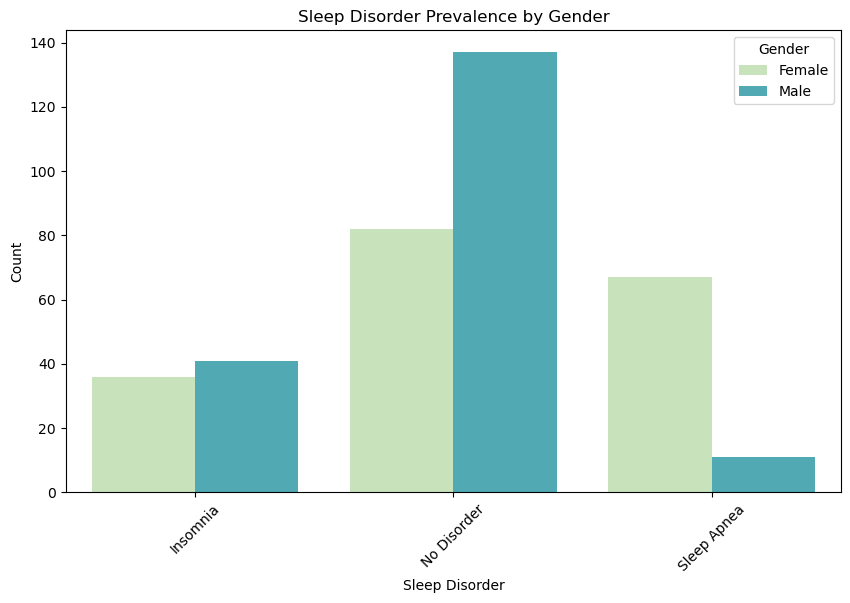

In [29]:
sleep_disorder_counts = df.groupby(['Gender', 'Sleep Disorder']).size().reset_index(name='Count')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Sleep Disorder', y='Count', hue='Gender', data=sleep_disorder_counts, palette=custom_palette, ax=ax)
ax.set_title('Sleep Disorder Prevalence by Gender')
ax.set_xlabel('Sleep Disorder')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Age

#### Age Distribution

#### What are the most common occupations among different age groups?


<Figure size 15000x1800 with 0 Axes>

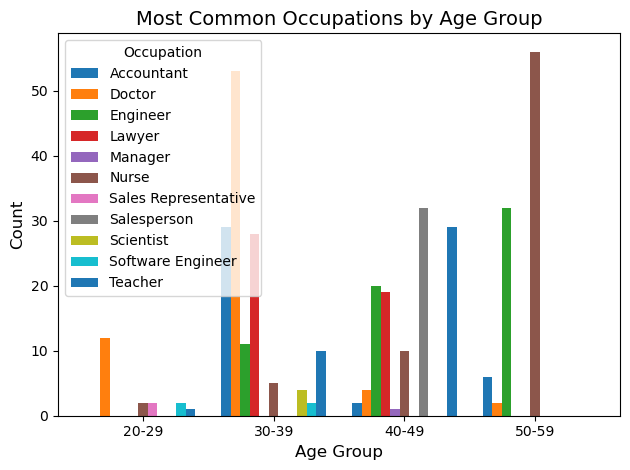

In [31]:
# Create age groups
bins = [20, 30, 40, 50, 60]
labels = ['20-29', '30-39', '40-49', '50-59']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Count occupations per age group
occupation_counts = df.groupby(['Age Group', 'Occupation']).size().reset_index(name='Count')

# Pivot the data for plotting
pivot_df = occupation_counts.pivot(index='Age Group', columns='Occupation', values='Count').fillna(0)

# Plot with wider bars and move the legend outside
plt.figure(figsize=(150, 18))  # Increase figure size
pivot_df.plot(kind='bar', width=0.8)  # Adjust `width` for bar thickness
plt.title('Most Common Occupations by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10, rotation=0)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### How does BMI category distribution differ across different age groups?

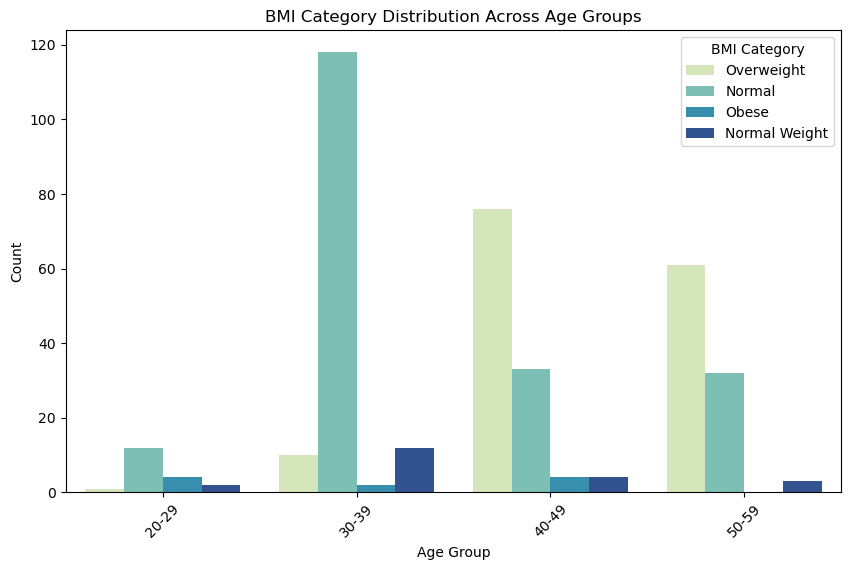

In [36]:
bins = [20, 30, 40, 50, 60]
labels = ['20-29', '30-39', '40-49', '50-59']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Create the plot
plt.figure(figsize=(10, 6))
sns.countplot(x='Age Group', hue='BMI Category', data=df, palette="YlGnBu")
plt.title('BMI Category Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Occupation

#### Distribution of Occupation

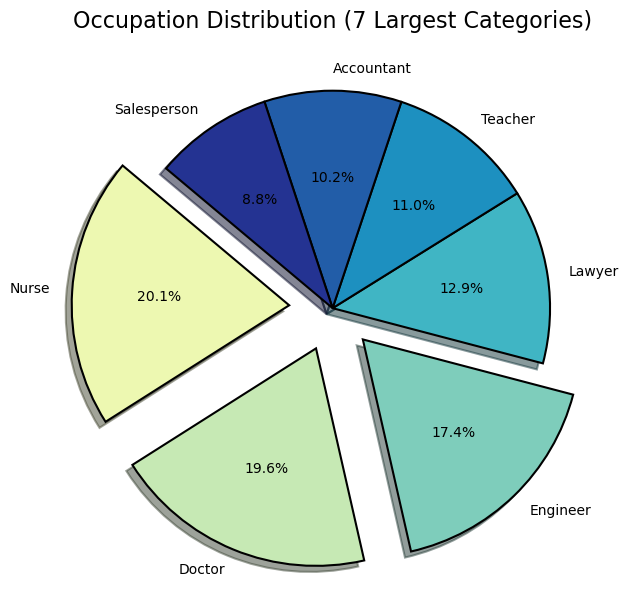

In [41]:
fig = plt.figure(figsize=(8, 6), facecolor='white')
ax = plt.subplot2grid((1, 1), (0, 0))

ax.set_facecolor('white')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

occupation_counts = df['Occupation'].value_counts().head(7)
colors = sns.color_palette("YlGnBu", len(occupation_counts))
explode = [0.2 if i < 3 else 0 for i in range(len(occupation_counts))]

ax.pie(occupation_counts, labels=occupation_counts.index, autopct='%1.1f%%', colors=colors,
       startangle=140, explode=explode, shadow=True, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax.set_title('Occupation Distribution (7 Largest Categories)', fontsize=16)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#### How does BMI category distribution differ across different occupations?

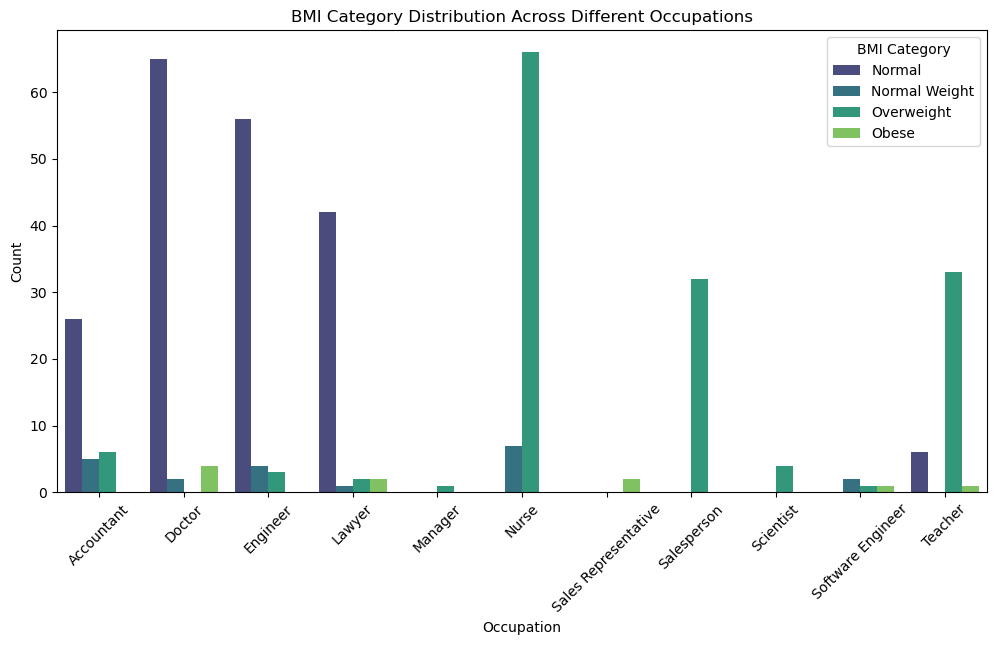

In [46]:
# Group data by occupation and BMI category, then count occurrences
bmi_by_occupation = df.groupby(['Occupation', 'BMI Category']).size().reset_index(name='Count')

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Occupation', y='Count', hue='BMI Category', data=bmi_by_occupation, palette='viridis')
plt.title('BMI Category Distribution Across Different Occupations')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

#### Are there differences in daily steps across different occupations?

Kruskal-Wallis statistic: 104.84394191484238
P-value: 5.821447451089556e-18
There is a statistically significant difference in daily steps across different occupations.


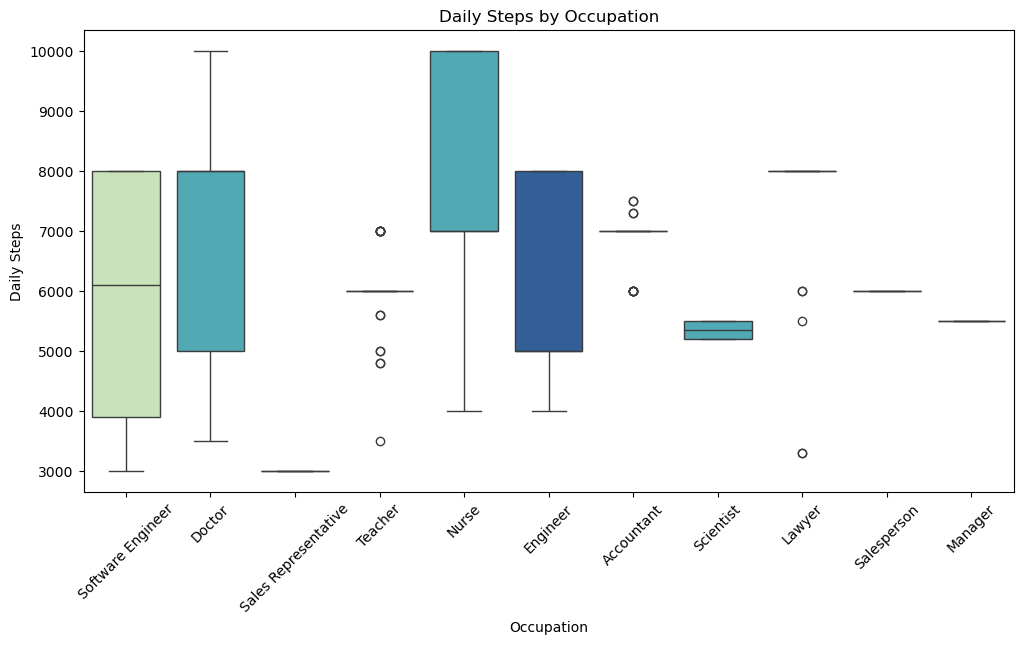

In [49]:
# Perform a statistical test (e.g., Kruskal-Wallis) to compare daily steps across occupations.
occupations = df['Occupation'].unique()
daily_steps_by_occupation = {}

for occupation in occupations:
    daily_steps_by_occupation[occupation] = df[df['Occupation'] == occupation]['Daily Steps']

statistic, p_value = kruskal(*daily_steps_by_occupation.values())

print(f"Kruskal-Wallis statistic: {statistic}")
print(f"P-value: {p_value}")

alpha = 0.05  # Set significance level

if p_value < alpha:
    print("There is a statistically significant difference in daily steps across different occupations.")
else:
    print("There is no statistically significant difference in daily steps across different occupations.")

# Visualization (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Occupation', y='Daily Steps', data=df, palette=custom_palette)
plt.title('Daily Steps by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Daily Steps')
plt.xticks(rotation=45)
plt.show()

Nurses and Engineers have a higher median than Software Engineers, meaning they typically walk more.

#### Is the prevalence of sleep disorders different across different occupations?

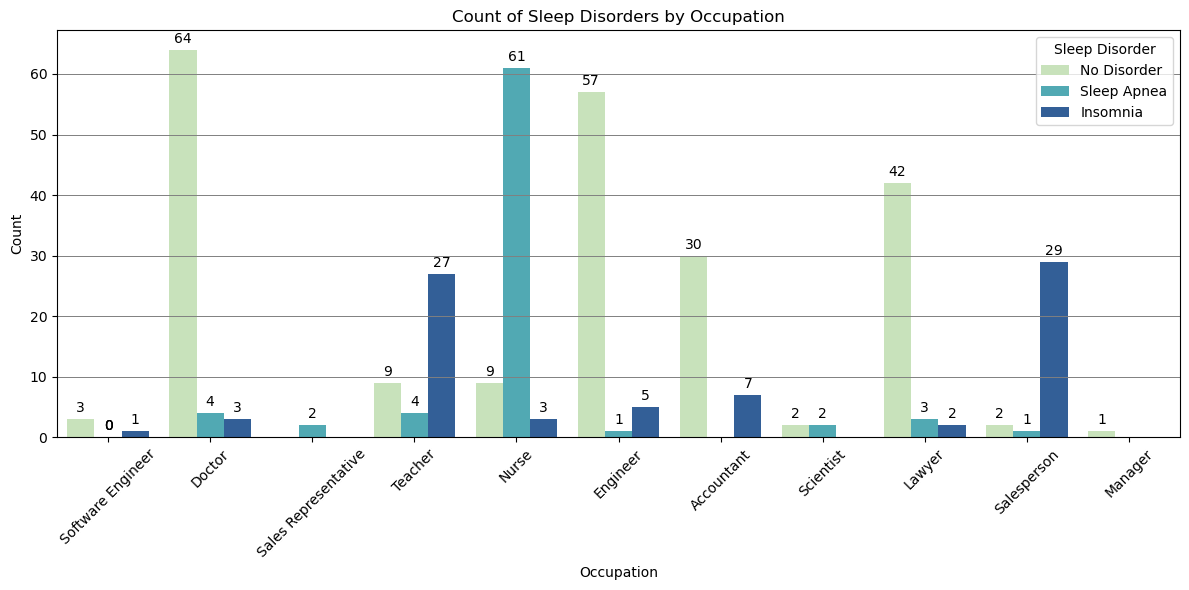

In [50]:
custom_palette = sns.color_palette("YlGnBu", 3)
plt.figure(figsize=(12, 6))

sns.countplot(x='Occupation', hue='Sleep Disorder', data=df, palette=custom_palette)
plt.title('Count of Sleep Disorders by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', color='gray', linewidth=0.7)
plt.legend(title='Sleep Disorder')

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline',
                 color='black', fontsize=10,
                 xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

### Do individuals with certain sleep disorders tend to have consistently shorter or longer sleep durations compared to those with no reported disorder, regardless of age?

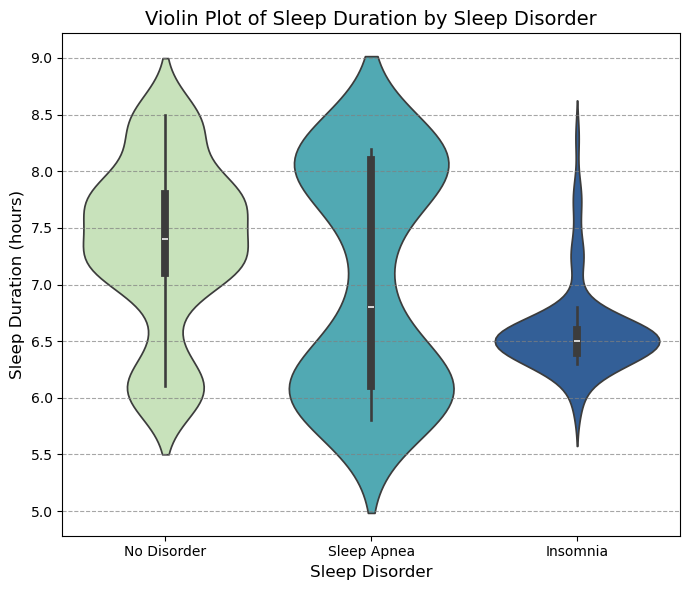

In [51]:

custom_palette = sns.color_palette("YlGnBu", 3)

fig, ax = plt.subplots(figsize=(7, 6))
sns.violinplot(
    x='Sleep Disorder', 
    y='Sleep Duration', 
    data=df, 
    palette=custom_palette, 
    ax=ax
)

ax.set_title('Violin Plot of Sleep Duration by Sleep Disorder', fontsize=14)
ax.set_xlabel('Sleep Disorder', fontsize=12)
ax.set_ylabel('Sleep Duration (hours)', fontsize=12)
ax.grid(axis='y', color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Are there significant differences in heart rate distributions between individuals with different sleep disorders?

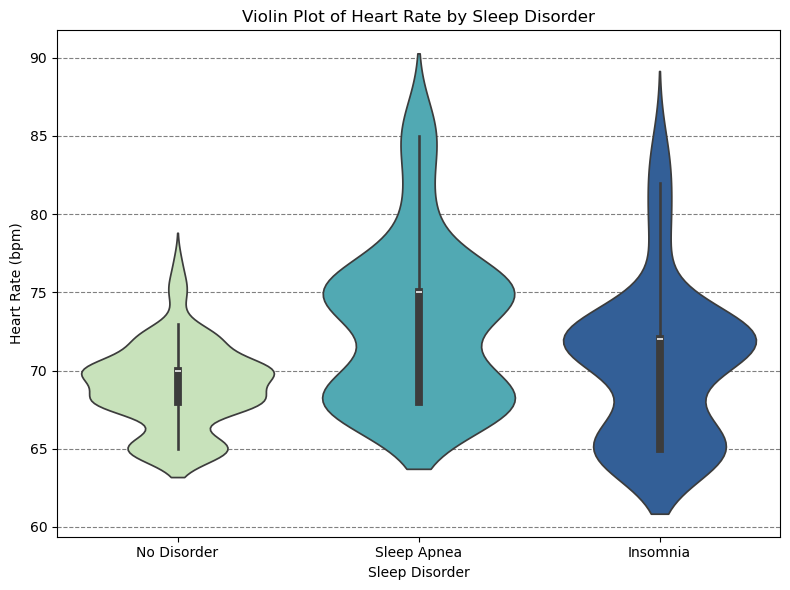

In [54]:

fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(x='Sleep Disorder', y='Heart Rate', data=df, palette=custom_palette, ax=ax)
ax.set_title('Violin Plot of Heart Rate by Sleep Disorder')
ax.set_xlabel('Sleep Disorder')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='--')

plt.tight_layout()
plt.show()


## Distribution of Sleep Disorder

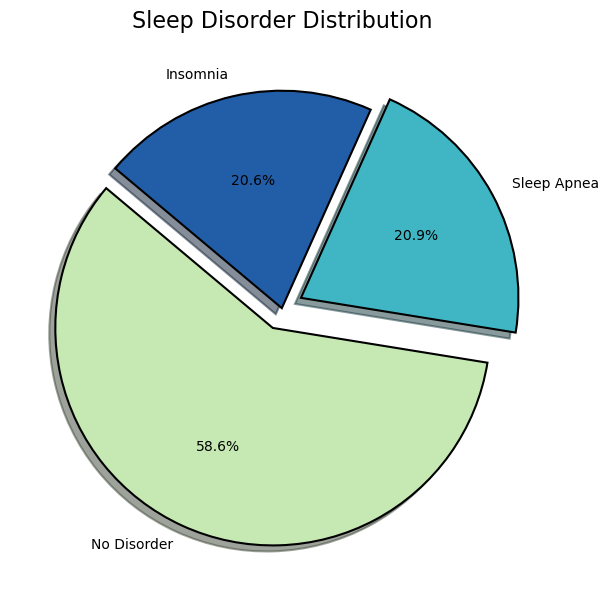

In [55]:
# Set up the figure
fig = plt.figure(figsize=(8, 6), facecolor='white')
ax = plt.subplot2grid((1, 1), (0, 0))

# Customize the plot
ax.set_facecolor('white')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Count the occurrences of each sleep disorder
sleep_disorder_counts = df['Sleep Disorder'].value_counts()

# Define colors and explode for the pie chart
colors = sns.color_palette("YlGnBu", len(sleep_disorder_counts))
explode = [0.1 if i < 2 else 0 for i in range(len(sleep_disorder_counts))]  # Explode the top 2 categories

# Plot the pie chart
ax.pie(sleep_disorder_counts, labels=sleep_disorder_counts.index, autopct='%1.1f%%', colors=colors,
       startangle=140, explode=explode, shadow=True, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax.set_title('Sleep Disorder Distribution', fontsize=16)
ax.set_aspect('equal')  # Ensure the pie chart is circular

plt.tight_layout()
plt.show()

## Correlation

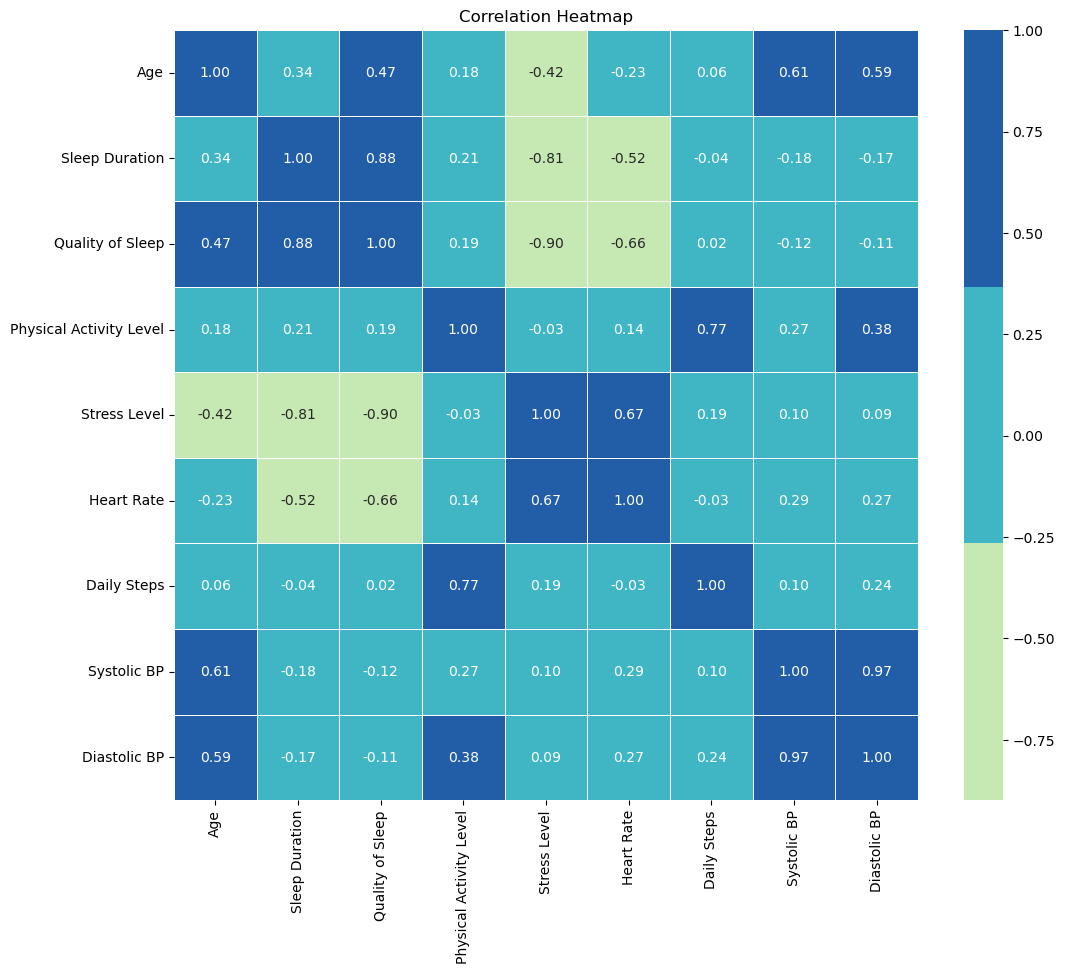

In [57]:
# Select the numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_palette, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

# **Algorithms**

## Working on Label Sleep Disorder Using RandomForest 

              precision    recall  f1-score   support

           0       0.76      0.81      0.79        16
           1       0.93      0.98      0.95        43
           2       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.85      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



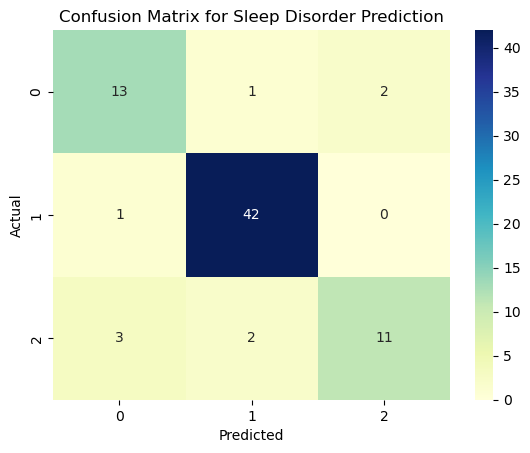

In [58]:
le_gender = LabelEncoder()
df_numeric['Gender'] = le_gender.fit_transform(df_numeric['Gender'])

# Features (X) and Target (y)
X = df_numeric.drop(['Sleep Disorder'], axis=1)
y = df_numeric['Sleep Disorder']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Train model
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap= "YlGnBu", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Sleep Disorder Prediction')
plt.show()

## Working on Label Sleep Disorder Using SVM 

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.79        16
           1       0.89      0.95      0.92        43
           2       0.92      0.69      0.79        16

    accuracy                           0.87        75
   macro avg       0.86      0.82      0.83        75
weighted avg       0.87      0.87      0.86        75



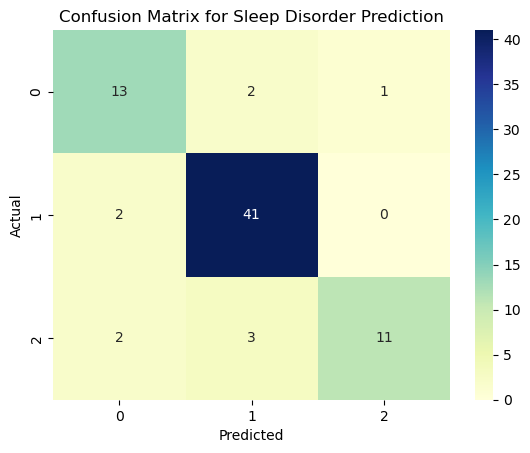

In [59]:
# Initialize SVM with class weights to handle imbalance
model = SVC(s
    kernel='rbf',          # Radial Basis Function kernel for non-linear relationships
    C=1.0,                 # Regularization parameter
    gamma='scale',         # Kernel coefficient
    class_weight='balanced', # Adjusts weights inversely proportional to class frequencies
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap= "YlGnBu", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Sleep Disorder Prediction')
plt.show()

## Working on Label Sleep Disorder Using Decision Tree

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        16
           1       0.91      0.98      0.94        43
           2       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.86      0.83      0.84        75
weighted avg       0.88      0.88      0.88        75



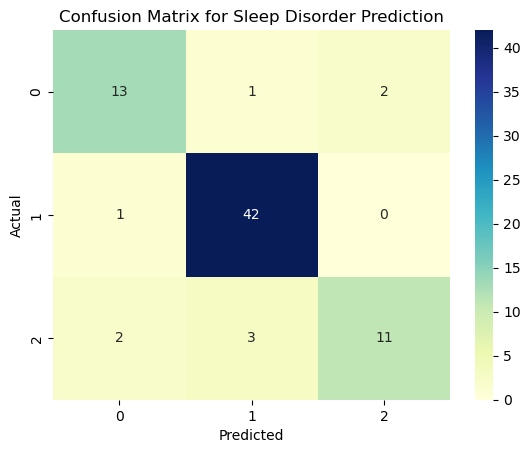

In [60]:
# Initialize and train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate performance using classification metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Sleep Disorder Prediction')
plt.show()

## Working on Label Sleep Disorder Using LogisticRegression

Accuracy: 0.88
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.95      0.95      0.95        43
           2       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.85      0.84      0.84        75
weighted avg       0.88      0.88      0.88        75



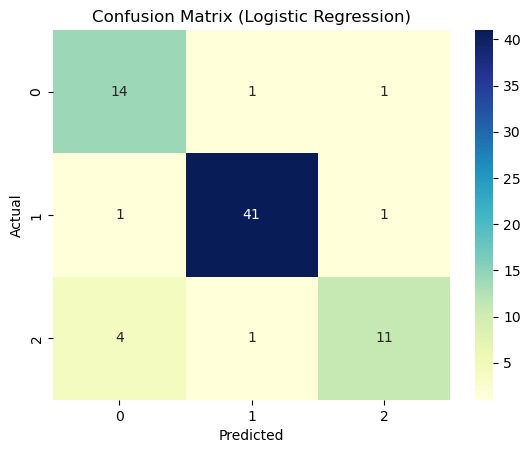

In [61]:
# Initialize and train the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation using classification metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

## Working on Label Stress Level Using Linear Regression 

RMSE: 0.3736444666719237
Mean Absolute Error: 0.20884365178983944
R^2 Score: 0.9553142537530259


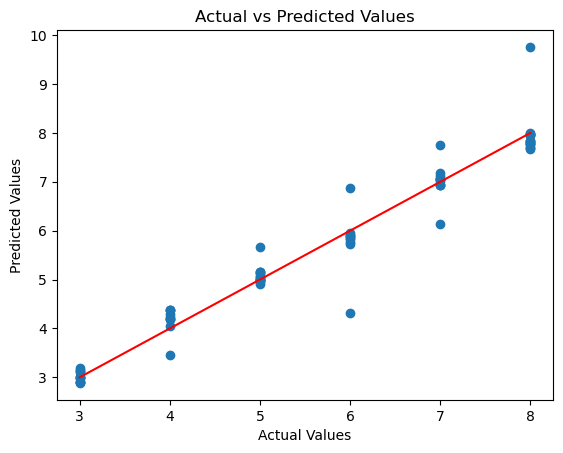

In [62]:
# Features (X) and Target (y)
X = df_numeric.drop(['Stress Level'], axis=1)
y = df_numeric['Stress Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Calculate RMSE using root_mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

# Additional metrics for evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

## Working on Label Stress Level Using Polynomial Regression

Polynomial Regression - Degree 6 - RMSE: 0.14757889459976123, R^2 Score: 0.9930289144765851


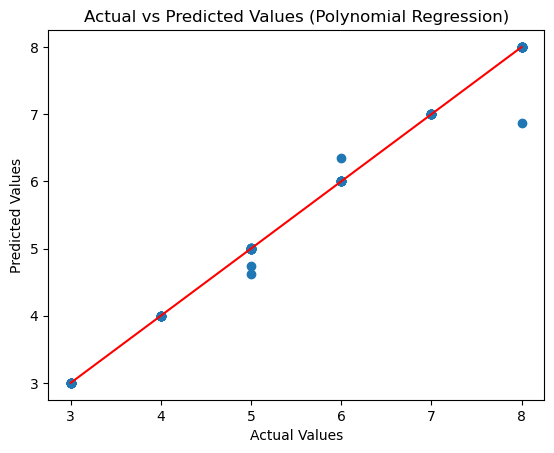

In [63]:

# Create polynomial features
degree = 6  # You can change this to any degree you want
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_pred = model.predict(X_test_poly)

# Evaluation using regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Regression - Degree {degree} - RMSE: {rmse}, R^2 Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (Polynomial Regression)')
plt.show()

## Working on Label Stress Level Using RandomForest

Random Forest Regressor - RMSE: 0.18657974166559455, MAE: 0.0569333333333333, R^2 Score: 0.9888575452372823


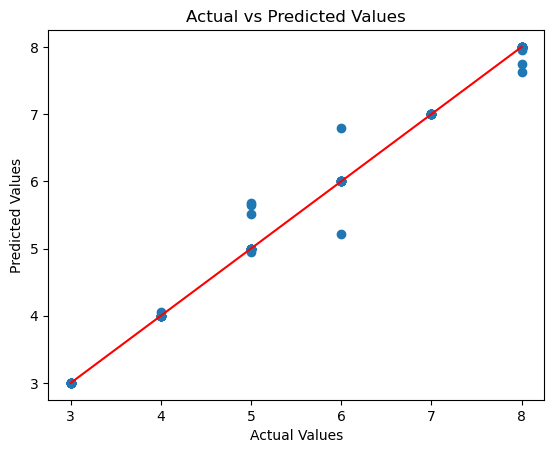

In [64]:
# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation using regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor - RMSE: {rmse}, MAE: {mae}, R^2 Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

## Working on Label Stress Level Using Decision Tree

Decision Tree Regressor - RMSE: 0.32659863237109044, MAE: 0.05333333333333334, R^2 Score: 0.9658586548310003


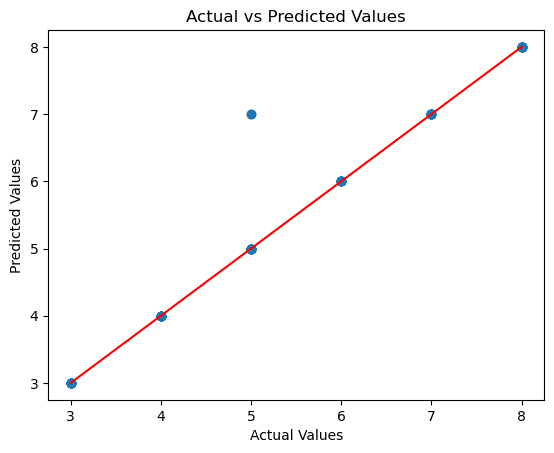

In [65]:
# Initialize and train the model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regressor - RMSE: {rmse}, MAE: {mae}, R^2 Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

## Working on Label Stress Level Using GradientBoostingRegressor 

RMSE: 0.08354429695296195
Mean Absolute Error: 0.03752165964635817
R^2 Score: 0.9977659878947492


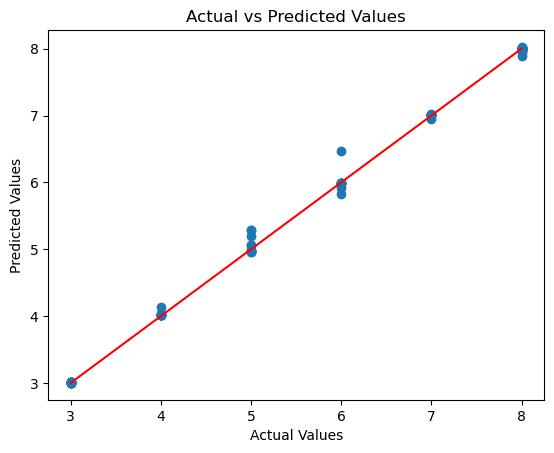

In [66]:
# Train model
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Calculate RMSE using root_mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

# Additional metrics for evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

# Plot actual vs predicted values
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()